# 🐕 Muffin vs Chihuahua — Competition Notebook
**4 Models | Auto Submission Format Detection | Best-2 CSV Export**

## 1. Setup & Imports

In [1]:
import os, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks
warnings.filterwarnings('ignore')

# ── Step 1: memory growth MUST come first, before ANY GPU op ────────────────
# If this is called after mixed_precision or jit, it is silently ignored.
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    tf.config.experimental.set_memory_growth(gpus[0], True)
    print('GPU memory growth enabled:', gpus[0].name)

# ── Step 2: mixed precision ──────────────────────────────────────────────────
# P100 (CC 6.0) has native FP16 units — halves activation memory.
tf.keras.mixed_precision.set_global_policy('mixed_float16')
print('Mixed precision:', tf.keras.mixed_precision.global_policy())

# ── Step 3: global XLA (graph-level only, no per-step retrace) ──────────────
# Do NOT set jit_compile=True in model.compile on P100 — it causes ~1s/step.
tf.config.optimizer.set_jit(True)
print('XLA global JIT:', tf.config.optimizer.get_jit())

print('TensorFlow:', tf.__version__)
print('GPU devices:', gpus)

2026-04-19 21:04:45.002871: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1776632685.184830      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1776632685.235788      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1776632685.667452      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1776632685.667490      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1776632685.667493      55 computation_placer.cc:177] computation placer alr

GPU memory growth enabled: /physical_device:GPU:0
Mixed precision: <DTypePolicy "mixed_float16">
XLA global JIT: autoclustering
TensorFlow: 2.19.0
GPU devices: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## 2. Paths & Global Config

In [3]:
IMG_SIZE   = (224, 224)
BATCH_SIZE = 64
SEED       = 42
VAL_SPLIT  = 0.2
AUTOTUNE   = tf.data.AUTOTUNE

BASE_INPUT = '/kaggle/input/competitions/cs-460-muffin-vs-chihuahua-classification-challenge'
TRAIN_DIR  = os.path.join(BASE_INPUT, 'train')
TEST_DIR   = os.path.join(BASE_INPUT, 'kaggle_test_final')
os.makedirs('/kaggle/working', exist_ok=True)


def make_tf_dataset(preprocess_fn, img_size=IMG_SIZE, batch_size=BATCH_SIZE):
    """
    GPU-correct pipeline:
      disk → decode → cache (RAM) → shuffle → batch → preprocess → prefetch

    Augmentation is intentionally absent here.
    It runs inside the model (first layer) on the GPU.
    """
    def apply_preprocess(x, y):
        return tf.cast(preprocess_fn(x), tf.float32), y

    raw_train = tf.keras.utils.image_dataset_from_directory(
        TRAIN_DIR,
        validation_split=VAL_SPLIT, subset='training',
        seed=SEED, image_size=img_size, batch_size=None,
    )
    raw_val = tf.keras.utils.image_dataset_from_directory(
        TRAIN_DIR,
        validation_split=VAL_SPLIT, subset='validation',
        seed=SEED, image_size=img_size, batch_size=None,
    )

    train_ds = (
        raw_train
        .cache()                              # decode once → serve from RAM epoch 2+
        .shuffle(4000, seed=SEED, reshuffle_each_iteration=True)
        .batch(batch_size, drop_remainder=True)
        .map(apply_preprocess, num_parallel_calls=AUTOTUNE)
        .prefetch(AUTOTUNE)                   # CPU prepares next batch while GPU trains
    )
    val_ds = (
        raw_val
        .cache()
        .batch(batch_size)
        .map(apply_preprocess, num_parallel_calls=AUTOTUNE)
        .prefetch(AUTOTUNE)
    )
    return train_ds, val_ds


PREPROCESS = {
    'efficientnet': tf.keras.applications.efficientnet.preprocess_input,
    'mobilenet':    tf.keras.applications.mobilenet_v2.preprocess_input,
    'resnet':       tf.keras.applications.resnet50.preprocess_input,
    'custom_cnn':   lambda x: x / 255.0,
}
print('Dataset builder ready ✅ (augmentation inside models = GPU)')

Dataset builder ready ✅ (augmentation inside models = GPU)


## 3. Submission Format Detection
> Reads `sample_submission.csv` (if available) and auto-detects column names, label format, and ID format so the generated CSV always matches what the leaderboard expects.

In [4]:
def detect_submission_format(base_input_dir):
    """
    Returns a dict describing the submission schema:
        id_col   : name of the ID column
        label_col: name of the label/prediction column
        id_has_ext: bool — does the ID include the .jpg extension?
        label_type: 'string' | 'int' | 'float'
        pos_label : which label value means the POSITIVE class
                    (None if unknown — strings are returned as-is)
        sample_df : the sample_submission dataframe, or None
    """
    schema = dict(
        id_col='ID', label_col='Label',   # safe defaults
        id_has_ext=True, label_type='string',
        pos_label=None, sample_df=None
    )

    # Search for a sample submission in common locations
    candidates = [
        os.path.join(base_input_dir, 'test_solution_01.csv'),
        '/kaggle/input/sample_submission.csv',
        '/kaggle/working/sample_submission.csv',
    ]
    sample_path = next((p for p in candidates if os.path.isfile(p)), None)

    if sample_path:
        df = pd.read_csv(sample_path)
        schema['sample_df'] = df
        cols = list(df.columns)
        print(f'✅ sample_submission.csv found: {sample_path}')
        print(f'   Columns  : {cols}')
        print(f'   First row: {df.iloc[0].to_dict()}')

        # ID column — first column by convention
        schema['id_col'] = cols[0]

        # Label column — last column (or second)
        schema['label_col'] = cols[-1]

        # Does the ID include the file extension?
        first_id = str(df.iloc[0, 0])
        schema['id_has_ext'] = any(
            first_id.lower().endswith(ext)
            for ext in ('.jpg', '.jpeg', '.png', '.webp')
        )

        # Label type
        lbl_dtype = df[schema['label_col']].dtype
        if np.issubdtype(lbl_dtype, np.integer):
            schema['label_type'] = 'int'
        elif np.issubdtype(lbl_dtype, np.floating):
            schema['label_type'] = 'float'
        else:
            schema['label_type'] = 'string'
    else:
        print('⚠️  No sample_submission.csv found — using defaults.')
        print('   Assumed columns: ID, Label  |  Labels: "chihuahua" / "muffin"')

    print(f'\n📋 Schema: {schema}')
    return schema


SCHEMA = detect_submission_format(BASE_INPUT)

✅ sample_submission.csv found: /kaggle/input/competitions/cs-460-muffin-vs-chihuahua-classification-challenge/test_solution_01.csv
   Columns  : ['ID', 'Label']
   First row: {'ID': 'img_0_0.jpg', 'Label': 'muffin'}

📋 Schema: {'id_col': 'ID', 'label_col': 'Label', 'id_has_ext': True, 'label_type': 'string', 'pos_label': None, 'sample_df':                   ID      Label
0        img_0_0.jpg     muffin
1       img_0_10.jpg     muffin
2     img_0_1000.jpg  chihuahua
3     img_0_1037.jpg  chihuahua
4      img_0_105.jpg  chihuahua
...              ...        ...
1133   img_4_979.jpg  chihuahua
1134   img_4_989.jpg     muffin
1135   img_4_991.jpg     muffin
1136   img_4_996.jpg  chihuahua
1137   img_4_997.jpg     muffin

[1138 rows x 2 columns]}


## 4. Class-Order Verification
> **Root cause of the 52% bug** — Keras sorts class names alphabetically, so `chihuahua=0, muffin=1`. We pin this mapping explicitly so it never drifts.

In [5]:
# Build a temp dataset just to read the class order — never train on it.
_probe_ds = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR, image_size=IMG_SIZE, batch_size=1, seed=SEED
)
CLASS_NAMES = _probe_ds.class_names   # e.g. ['chihuahua', 'muffin']
del _probe_ds

print('Class names (alphabetical):', CLASS_NAMES)
# Sigmoid output → index 1 class → muffin (if alphabetical order holds)
# Index mapping: 0 → CLASS_NAMES[0], 1 → CLASS_NAMES[1]

def sigmoid_to_label(prob, threshold=0.5):
    """Map sigmoid probability to string label."""
    return CLASS_NAMES[1] if prob >= threshold else CLASS_NAMES[0]

print(f'\nsigmoid ≥ 0.5  →  "{CLASS_NAMES[1]}"')
print(f'sigmoid <  0.5  →  "{CLASS_NAMES[0]}"')

Found 4733 files belonging to 2 classes.


I0000 00:00:1776632745.998719      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


Class names (alphabetical): ['chihuahua', 'muffin']

sigmoid ≥ 0.5  →  "muffin"
sigmoid <  0.5  →  "chihuahua"


## 6. Shared Training Utilities

In [6]:
def get_callbacks(model_name, patience_es=5, patience_lr=3):
    """EarlyStopping + ReduceLROnPlateau + ModelCheckpoint."""
    ckpt_path = f'/kaggle/working/{model_name}_best.keras'
    return [
        callbacks.EarlyStopping(
            monitor='val_accuracy', patience=patience_es,
            restore_best_weights=True, verbose=1
        ),
        callbacks.ReduceLROnPlateau(
            monitor='val_loss', factor=0.3, patience=patience_lr,
            min_lr=1e-7, verbose=1
        ),
        callbacks.ModelCheckpoint(
            ckpt_path, monitor='val_accuracy',
            save_best_only=True, verbose=0
        ),
    ]

def plot_history(histories, names):
    n = len(histories)
    fig, axes = plt.subplots(2, n, figsize=(5*n, 8))
    for i, (hist, name) in enumerate(zip(histories, names)):
        axes[0, i].plot(hist.history['accuracy'],     label='train')
        axes[0, i].plot(hist.history['val_accuracy'], label='val')
        axes[0, i].set_title(f'{name}\nAccuracy')
        axes[0, i].legend(); axes[0, i].grid(True)

        axes[1, i].plot(hist.history['loss'],     label='train')
        axes[1, i].plot(hist.history['val_loss'], label='val')
        axes[1, i].set_title(f'{name}\nLoss')
        axes[1, i].legend(); axes[1, i].grid(True)
    plt.tight_layout()
    plt.savefig('/kaggle/working/training_curves.png', dpi=120)
    plt.show()

print('Callback & plot utilities ready ✅')

Callback & plot utilities ready ✅


In [7]:
# Shared GPU augmentation block.
# As the first layer in every model, it executes during the GPU forward pass.
GPU_AUGMENT = tf.keras.Sequential([
    layers.RandomFlip('horizontal'),
    layers.RandomRotation(0.15),
    layers.RandomZoom(0.15),
    layers.RandomContrast(0.1),
    layers.RandomBrightness(0.1),
    layers.RandomTranslation(0.05, 0.05),
], name='gpu_augmentation')


def build_head(base_model, name):
    inp = tf.keras.Input(shape=(*IMG_SIZE, 3), name='image_input')
    x   = GPU_AUGMENT(inp)                  # augment on GPU
    x   = base_model(x, training=False)
    x   = layers.GlobalAveragePooling2D()(x)
    x   = layers.BatchNormalization()(x)
    x   = layers.Dense(256, activation='relu')(x)
    x   = layers.Dropout(0.4)(x)
    out = layers.Dense(1, activation='sigmoid',
                       dtype='float32', name='output')(x)  # float32 for stability
    return tf.keras.Model(inp, out, name=name)


def compile_model(model, lr=1e-3):
    """No jit_compile — P100 CC 6.0 XLA retracing cost > benefit."""
    model.compile(
        optimizer=tf.keras.optimizers.Adam(lr),
        loss='binary_crossentropy',
        metrics=['accuracy'],
    )


def get_callbacks(model_name, patience_es=5, patience_lr=3):
    ckpt_path = f'/kaggle/working/{model_name}_best.keras'
    return [
        callbacks.EarlyStopping(
            monitor='val_accuracy', patience=patience_es,
            restore_best_weights=True, verbose=1
        ),
        callbacks.ReduceLROnPlateau(
            monitor='val_loss', factor=0.3, patience=patience_lr,
            min_lr=1e-7, verbose=1
        ),
        callbacks.ModelCheckpoint(
            ckpt_path, monitor='val_accuracy',
            save_best_only=True, verbose=0
        ),
    ]

print('Model builder ready ✅')
print('Expected step time: ~130-200 ms (vs 1000 ms with jit_compile)')

Model builder ready ✅
Expected step time: ~130-200 ms (vs 1000 ms with jit_compile)


In [8]:
with tf.device('/GPU:0'):
    dummy = tf.random.normal([4, 224, 224, 3])
    out   = GPU_AUGMENT(dummy, training=True)
print('Augmentation device check OK, output shape:', out.shape)

import subprocess
r = subprocess.run(
    ['nvidia-smi', '--query-gpu=name,utilization.gpu,memory.used,memory.total',
     '--format=csv,noheader,nounits'],
    capture_output=True, text=True
)
print('\nnvidia-smi:')
for line in r.stdout.strip().splitlines():
    name, util, used, total = [v.strip() for v in line.split(',')]
    print(f'  {name}  |  util={util}%  |  VRAM={used}/{total} MiB')
print('\nDuring training: util should be >70%, VRAM ~8-12 GB.')

Augmentation device check OK, output shape: (4, 224, 224, 3)

nvidia-smi:
  Tesla P100-PCIE-16GB  |  util=0%  |  VRAM=291/16384 MiB

During training: util should be >70%, VRAM ~8-12 GB.


## 7. Model 1 — EfficientNetB0

In [9]:
train_ds1, val_ds1 = make_tf_dataset(PREPROCESS['efficientnet'])

base1 = tf.keras.applications.EfficientNetB0(
    include_top=False, weights='imagenet', input_shape=(*IMG_SIZE, 3)
)
base1.trainable = False
model1 = build_head(base1, 'Model1_EfficientNetB0')

compile_model(model1, lr=1e-3)
print('=== Model 1 — Phase 1: Frozen backbone ===')
history1_p1 = model1.fit(
    train_ds1, validation_data=val_ds1, epochs=10,
    callbacks=get_callbacks('model1_p1', patience_es=4)
)

print('\n=== Model 1 — Phase 2: Fine-tuning top 30 layers ===')
base1.trainable = True
for layer in base1.layers[:-30]: layer.trainable = False
compile_model(model1, lr=1e-5)
history1_p2 = model1.fit(
    train_ds1, validation_data=val_ds1, epochs=10,
    callbacks=get_callbacks('model1_p2', patience_es=5)
)
val_acc1 = max(history1_p2.history['val_accuracy'])
print(f'\n✅ Model 1 best val_accuracy: {val_acc1:.4f}')

Found 4733 files belonging to 2 classes.
Using 3787 files for training.
Found 4733 files belonging to 2 classes.
Using 946 files for validation.
16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
=== Model 1 — Phase 1: Frozen backbone ===
Epoch 1/10


I0000 00:00:1776632789.847411     134 service.cc:152] XLA service 0x7fa2780071b0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1776632789.847447     134 service.cc:160]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1776632789.883307     134 cuda_dnn.cc:529] Loaded cuDNN version 91002
I0000 00:00:1776632790.022984     134 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.
E0000 00:00:1776632795.158254      55 meta_optimizer.cc:967] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inStatefulPartitionedCall/Model1_EfficientNetB0_1/efficientnetb0_1/block2b_drop_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer


59/59 ━━━━━━━━━━━━━━━━━━━━ 89s 575ms/step - accuracy: 0.9172 - loss: 0.1901 - val_accuracy: 0.9937 - val_loss: 0.0209 - learning_rate: 0.0010
Epoch 2/10
59/59 ━━━━━━━━━━━━━━━━━━━━ 28s 479ms/step - accuracy: 0.9866 - loss: 0.0459 - val_accuracy: 0.9958 - val_loss: 0.0149 - learning_rate: 0.0010
Epoch 3/10
59/59 ━━━━━━━━━━━━━━━━━━━━ 4s 61ms/step - accuracy: 0.9851 - loss: 0.0450 - val_accuracy: 0.9947 - val_loss: 0.0115 - learning_rate: 0.0010
Epoch 4/10
59/59 ━━━━━━━━━━━━━━━━━━━━ 4s 61ms/step - accuracy: 0.9913 - loss: 0.0232 - val_accuracy: 0.9958 - val_loss: 0.0097 - learning_rate: 0.0010
Epoch 5/10
59/59 ━━━━━━━━━━━━━━━━━━━━ 4s 61ms/step - accuracy: 0.9958 - loss: 0.0095 - val_accuracy: 0.9947 - val_loss: 0.0087 - learning_rate: 0.0010
Epoch 6/10
59/59 ━━━━━━━━━━━━━━━━━━━━ 4s 73ms/step - accuracy: 0.9968 - loss: 0.0090 - val_accuracy: 0.9968 - val_loss: 0.0060 - learning_rate: 0.0010
Epoch 7/10
59/59 ━━━━━━━━━━━━━━━━━━━━ 4s 74ms/step - accuracy: 0.9958 - loss: 0.0146 - val_accuracy: 

E0000 00:00:1776632947.078127      55 meta_optimizer.cc:967] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inStatefulPartitionedCall/Model1_EfficientNetB0_1/efficientnetb0_1/block2b_drop_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer


59/59 ━━━━━━━━━━━━━━━━━━━━ 64s 338ms/step - accuracy: 0.9782 - loss: 0.0543 - val_accuracy: 0.9979 - val_loss: 0.0066 - learning_rate: 1.0000e-05
Epoch 2/10
59/59 ━━━━━━━━━━━━━━━━━━━━ 15s 255ms/step - accuracy: 0.9868 - loss: 0.0327 - val_accuracy: 0.9968 - val_loss: 0.0093 - learning_rate: 1.0000e-05
Epoch 3/10
59/59 ━━━━━━━━━━━━━━━━━━━━ 4s 68ms/step - accuracy: 0.9875 - loss: 0.0333 - val_accuracy: 0.9958 - val_loss: 0.0107 - learning_rate: 1.0000e-05
Epoch 4/10
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step - accuracy: 0.9903 - loss: 0.0320
Epoch 4: ReduceLROnPlateau reducing learning rate to 2.9999999242136253e-06.
59/59 ━━━━━━━━━━━━━━━━━━━━ 4s 68ms/step - accuracy: 0.9903 - loss: 0.0320 - val_accuracy: 0.9947 - val_loss: 0.0111 - learning_rate: 1.0000e-05
Epoch 5/10
59/59 ━━━━━━━━━━━━━━━━━━━━ 4s 69ms/step - accuracy: 0.9916 - loss: 0.0225 - val_accuracy: 0.9947 - val_loss: 0.0121 - learning_rate: 3.0000e-06
Epoch 6/10
59/59 ━━━━━━━━━━━━━━━━━━━━ 4s 69ms/step - accuracy: 0.9905 - loss: 0.0

## 8. Model 2 — MobileNetV2

In [10]:
train_ds2, val_ds2 = make_tf_dataset(PREPROCESS['mobilenet'])

base2 = tf.keras.applications.MobileNetV2(
    include_top=False, weights='imagenet', input_shape=(*IMG_SIZE, 3)
)
base2.trainable = False
model2 = build_head(base2, 'Model2_MobileNetV2')

compile_model(model2, lr=1e-3)
print('=== Model 2 — Phase 1: Frozen backbone ===')
history2_p1 = model2.fit(
    train_ds2, validation_data=val_ds2, epochs=10,
    callbacks=get_callbacks('model2_p1', patience_es=4)
)

print('\n=== Model 2 — Phase 2: Fine-tuning top 30 layers ===')
base2.trainable = True
for layer in base2.layers[:-30]:
    layer.trainable = False

compile_model(model2, lr=1e-5)
history2_p2 = model2.fit(
    train_ds2, validation_data=val_ds2, epochs=10,
    callbacks=get_callbacks('model2_p2', patience_es=5)
)

val_acc2 = max(history2_p2.history['val_accuracy'])
print(f'\n✅ Model 2 best val_accuracy: {val_acc2:.4f}')

Found 4733 files belonging to 2 classes.
Using 3787 files for training.
Found 4733 files belonging to 2 classes.
Using 946 files for validation.
9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
=== Model 2 — Phase 1: Frozen backbone ===
Epoch 1/10
59/59 ━━━━━━━━━━━━━━━━━━━━ 54s 371ms/step - accuracy: 0.6017 - loss: 0.8175 - val_accuracy: 0.9630 - val_loss: 0.1423 - learning_rate: 0.0010
Epoch 2/10
59/59 ━━━━━━━━━━━━━━━━━━━━ 19s 320ms/step - accuracy: 0.6346 - loss: 0.7187 - val_accuracy: 0.9789 - val_loss: 0.0936 - learning_rate: 0.0010
Epoch 3/10
59/59 ━━━━━━━━━━━━━━━━━━━━ 3s 52ms/step - accuracy: 0.6682 - loss: 0.6380 - val_accuracy: 0.9355 - val_loss: 0.1626 - learning_rate: 0.0010
Epoch 4/10
59/59 ━━━━━━━━━━━━━━━━━━━━ 3s 53ms/step - accuracy: 0.6606 - loss: 0.6310 - val_accuracy: 0.9736 - val_loss: 0.0902 - learning_rate: 0.0010
Epoch 5/10
59/59 ━━━━━━━━━━━━━━━━━━━━ 3s 52ms/step - accuracy: 0.6853 - loss: 0.5998 - val_accuracy: 0.9767 - val_loss: 0.0692 - learning_rate: 0.0010
Epoc

## 9. Model 3 — ResNet50

In [11]:
train_ds3, val_ds3 = make_tf_dataset(PREPROCESS['resnet'])

base3 = tf.keras.applications.ResNet50(
    include_top=False, weights='imagenet', input_shape=(*IMG_SIZE, 3)
)
base3.trainable = False
model3 = build_head(base3, 'Model3_ResNet50')

compile_model(model3, lr=1e-3)
print('=== Model 3 — Phase 1: Frozen backbone ===')
history3_p1 = model3.fit(
    train_ds3, validation_data=val_ds3, epochs=10,
    callbacks=get_callbacks('model3_p1', patience_es=4)
)

print('\n=== Model 3 — Phase 2: Fine-tuning last ResNet block ===')
base3.trainable = True
for layer in base3.layers[:-35]:
    layer.trainable = False

compile_model(model3, lr=1e-5)
history3_p2 = model3.fit(
    train_ds3, validation_data=val_ds3, epochs=10,
    callbacks=get_callbacks('model3_p2', patience_es=5)
)

val_acc3 = max(history3_p2.history['val_accuracy'])
print(f'\n✅ Model 3 best val_accuracy: {val_acc3:.4f}')

Found 4733 files belonging to 2 classes.
Using 3787 files for training.
Found 4733 files belonging to 2 classes.
Using 946 files for validation.
94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
=== Model 3 — Phase 1: Frozen backbone ===
Epoch 1/10
59/59 ━━━━━━━━━━━━━━━━━━━━ 40s 268ms/step - accuracy: 0.9158 - loss: 0.2349 - val_accuracy: 0.9852 - val_loss: 0.0331 - learning_rate: 0.0010
Epoch 2/10
59/59 ━━━━━━━━━━━━━━━━━━━━ 12s 210ms/step - accuracy: 0.9675 - loss: 0.0777 - val_accuracy: 0.9926 - val_loss: 0.0205 - learning_rate: 0.0010
Epoch 3/10
59/59 ━━━━━━━━━━━━━━━━━━━━ 7s 117ms/step - accuracy: 0.9814 - loss: 0.0528 - val_accuracy: 0.9894 - val_loss: 0.0237 - learning_rate: 0.0010
Epoch 4/10
59/59 ━━━━━━━━━━━━━━━━━━━━ 7s 117ms/step - accuracy: 0.9790 - loss: 0.0628 - val_accuracy: 0.9915 - val_loss: 0.0278 - learning_rate: 0.0010
Epoch 5/10
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step - accuracy: 0.9862 - loss: 0.0337
Epoch 5: ReduceLROnPlateau reducing learning rate to 0.00030000001

## 10. Model 4 — Custom CNN

In [12]:
train_ds4, val_ds4 = make_tf_dataset(PREPROCESS['custom_cnn'])

inp4 = tf.keras.Input(shape=(*IMG_SIZE, 3))
x = layers.Conv2D(32, 3, padding='same', activation='relu')(inp4)
x = layers.Conv2D(32, 3, padding='same', activation='relu')(x)
x = layers.BatchNormalization()(x)
x = layers.MaxPooling2D(2)(x)
x = layers.Dropout(0.25)(x)

x = layers.Conv2D(64, 3, padding='same', activation='relu')(x)
x = layers.Conv2D(64, 3, padding='same', activation='relu')(x)
x = layers.BatchNormalization()(x)
x = layers.MaxPooling2D(2)(x)
x = layers.Dropout(0.25)(x)

x = layers.Conv2D(128, 3, padding='same', activation='relu')(x)
x = layers.Conv2D(128, 3, padding='same', activation='relu')(x)
x = layers.BatchNormalization()(x)
x = layers.MaxPooling2D(2)(x)
x = layers.Dropout(0.3)(x)

x = layers.Conv2D(256, 3, padding='same', activation='relu')(x)
x = layers.BatchNormalization()(x)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(256, activation='relu')(x)
x = layers.Dropout(0.5)(x)
out4 = layers.Dense(1, activation='sigmoid', dtype='float32')(x)
model4 = tf.keras.Model(inp4, out4, name='Model4_CustomCNN')

compile_model(model4, lr=1e-3)
print('=== Model 4 — Custom CNN ===')
history4 = model4.fit(
    train_ds4, validation_data=val_ds4, epochs=20,
    callbacks=get_callbacks('model4', patience_es=6, patience_lr=4)
)

val_acc4 = max(history4.history['val_accuracy'])
print(f'\n✅ Model 4 best val_accuracy: {val_acc4:.4f}')

Found 4733 files belonging to 2 classes.
Using 3787 files for training.
Found 4733 files belonging to 2 classes.
Using 946 files for validation.
=== Model 4 — Custom CNN ===
Epoch 1/20
59/59 ━━━━━━━━━━━━━━━━━━━━ 68s 331ms/step - accuracy: 0.7602 - loss: 0.5213 - val_accuracy: 0.5307 - val_loss: 1.6656 - learning_rate: 0.0010
Epoch 2/20
59/59 ━━━━━━━━━━━━━━━━━━━━ 9s 147ms/step - accuracy: 0.8575 - loss: 0.3435 - val_accuracy: 0.5307 - val_loss: 2.8211 - learning_rate: 0.0010
Epoch 3/20
59/59 ━━━━━━━━━━━━━━━━━━━━ 9s 146ms/step - accuracy: 0.8759 - loss: 0.3285 - val_accuracy: 0.5307 - val_loss: 3.6150 - learning_rate: 0.0010
Epoch 4/20
59/59 ━━━━━━━━━━━━━━━━━━━━ 9s 146ms/step - accuracy: 0.8731 - loss: 0.3244 - val_accuracy: 0.5307 - val_loss: 2.2491 - learning_rate: 0.0010
Epoch 5/20
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 134ms/step - accuracy: 0.8880 - loss: 0.2600
Epoch 5: ReduceLROnPlateau reducing learning rate to 0.0003000000142492354.
59/59 ━━━━━━━━━━━━━━━━━━━━ 9s 146ms/step - accuracy: 0.

## 11. Model Selection — Best 2

In [13]:
model_registry = [
    {'name': 'Model1_EfficientNetB0', 'model': model1,
     'val_acc': val_acc1, 'preprocess': PREPROCESS['efficientnet']},
    {'name': 'Model2_MobileNetV2',    'model': model2,
     'val_acc': val_acc2, 'preprocess': PREPROCESS['mobilenet']},
    {'name': 'Model3_ResNet50',       'model': model3,
     'val_acc': val_acc3, 'preprocess': PREPROCESS['resnet']},
    {'name': 'Model4_CustomCNN',      'model': model4,
     'val_acc': val_acc4, 'preprocess': PREPROCESS['custom_cnn']},
]

# Sort by validation accuracy and pick top 2
model_registry.sort(key=lambda m: m['val_acc'], reverse=True)

print('🏆 Model Rankings:')
for rank, m in enumerate(model_registry, 1):
    tag = '🥇' if rank == 1 else '🥈' if rank == 2 else '  '
    print(f'  {tag} Rank {rank}: {m["name"]}  —  val_accuracy = {m["val_acc"]:.4f}')

best_two = model_registry[:2]
print(f'\n📌 Generating submissions for: {[m["name"] for m in best_two]}')

🏆 Model Rankings:
  🥇 Rank 1: Model1_EfficientNetB0  —  val_accuracy = 0.9979
  🥈 Rank 2: Model3_ResNet50  —  val_accuracy = 0.9915
     Rank 3: Model2_MobileNetV2  —  val_accuracy = 0.9799
     Rank 4: Model4_CustomCNN  —  val_accuracy = 0.9440

📌 Generating submissions for: ['Model1_EfficientNetB0', 'Model3_ResNet50']


## 12. Build Test Tensor

In [14]:
VALID_EXT = ('.jpg', '.jpeg', '.png', '.webp', '.bmp')

test_paths = sorted([
    os.path.join(TEST_DIR, f)
    for f in os.listdir(TEST_DIR)
    if f.lower().endswith(VALID_EXT)
])

# Build IDs matching the submission format detected earlier
raw_fnames = [os.path.basename(p) for p in test_paths]
if SCHEMA['id_has_ext']:
    test_ids = raw_fnames                              # e.g. img_0_0.jpg
else:
    test_ids = [os.path.splitext(f)[0] for f in raw_fnames]  # e.g. img_0_0

print(f'Total test images : {len(test_paths)}')
print(f'ID format (sample): {test_ids[:3]}')

# ── Load and preprocess as a raw uint8 array (preprocessing per-model later) ──
def load_images_raw(paths, img_size=IMG_SIZE):
    """Load images as uint8 numpy array — preprocessing applied per-model."""
    imgs = []
    for p in paths:
        img = tf.keras.utils.load_img(p, target_size=img_size)
        imgs.append(tf.keras.utils.img_to_array(img))  # float32 0-255
    return np.array(imgs, dtype=np.float32)

print('Loading test images...')
TEST_IMAGES_RAW = load_images_raw(test_paths)
print(f'Test array shape: {TEST_IMAGES_RAW.shape}')

Total test images : 1138
ID format (sample): ['img_0_0.jpg', 'img_0_10.jpg', 'img_0_1000.jpg']
Loading test images...
Test array shape: (1138, 224, 224, 3)


## 13. Prediction with Test-Time Augmentation (TTA)

In [17]:
def predict_with_tta(model, raw_images, preprocess_fn, n_tta=5, batch_size=32):
    """
    Test-Time Augmentation: average predictions over n_tta random augmentations.
    Returns probability array (N,).
    """
    tta_aug = tf.keras.Sequential([
        layers.RandomFlip('horizontal'),
        layers.RandomRotation(0.05),
        layers.RandomZoom(0.05),
    ])

    all_probs = []
    for t in range(n_tta):
        augmented = tta_aug(raw_images, training=True).numpy()
        preprocessed = preprocess_fn(augmented)
        probs = model.predict(preprocessed, batch_size=batch_size, verbose=0)
        all_probs.append(probs.flatten())
        print(f'  TTA pass {t+1}/{n_tta} done', end='\r')

    return np.mean(all_probs, axis=0)   # shape (N,)

print('TTA prediction utility ready ✅')

TTA prediction utility ready ✅


## 14. Generate Submissions for Best 2 Models

In [18]:
def build_submission(probs, test_ids, schema, threshold=0.5):
    """
    Convert probability array to a properly-formatted submission DataFrame.
    Handles string labels, integer (0/1), and float probability submissions.
    """
    label_type = schema['label_type']

    if label_type == 'string':
        # Most common: chihuahua / muffin (or similar text labels)
        labels = [sigmoid_to_label(p, threshold) for p in probs]
    elif label_type == 'int':
        # 0 / 1 encoding
        labels = [(1 if p >= threshold else 0) for p in probs]
    elif label_type == 'float':
        # Raw probability submission
        labels = probs.tolist()
    else:
        labels = [sigmoid_to_label(p, threshold) for p in probs]

    df = pd.DataFrame({
        schema['id_col']:    test_ids,
        schema['label_col']: labels,
    })

    # Sanity checks
    assert len(df) == len(test_ids), 'Row count mismatch!'
    assert df[schema['id_col']].nunique() == len(df), 'Duplicate IDs found!'
    assert df[schema['label_col']].notna().all(), 'NaN labels found!'

    return df


output_paths = []

for rank, entry in enumerate(best_two, 1):
    mname = entry['name']
    mdl   = entry['model']
    prep  = entry['preprocess']
    vacc  = entry['val_acc']

    print(f'\n━━━ Rank {rank}: {mname}  (val_acc={vacc:.4f}) ━━━')
    probs = predict_with_tta(mdl, TEST_IMAGES_RAW, prep, n_tta=5)

    df_sub = build_submission(probs, test_ids, SCHEMA)

    out_path = f'/kaggle/working/submission_rank{rank}_{mname}.csv'
    df_sub.to_csv(out_path, index=False)
    output_paths.append(out_path)

    # Preview
    print(f'✅ Saved: {out_path}')
    print(f'   Rows  : {len(df_sub)}')
    print(f'   Cols  : {list(df_sub.columns)}')
    print(f'   Dist  : {df_sub[SCHEMA["label_col"]].value_counts().to_dict()}')
    print(df_sub.head(5).to_string(index=False))

print('\n' + '='*60)
print('📦 Generated submission files:')
for p in output_paths:
    print(f'   → {p}')


━━━ Rank 1: Model1_EfficientNetB0  (val_acc=0.9979) ━━━
✅ Saved: /kaggle/working/submission_rank1_Model1_EfficientNetB0.csv
   Rows  : 1138
   Cols  : ['ID', 'Label']
   Dist  : {'chihuahua': 638, 'muffin': 500}
            ID  Label
   img_0_0.jpg muffin
  img_0_10.jpg muffin
img_0_1000.jpg muffin
img_0_1037.jpg muffin
 img_0_105.jpg muffin

━━━ Rank 2: Model3_ResNet50  (val_acc=0.9915) ━━━
✅ Saved: /kaggle/working/submission_rank2_Model3_ResNet50.csv
   Rows  : 1138
   Cols  : ['ID', 'Label']
   Dist  : {'chihuahua': 644, 'muffin': 494}
            ID  Label
   img_0_0.jpg muffin
  img_0_10.jpg muffin
img_0_1000.jpg muffin
img_0_1037.jpg muffin
 img_0_105.jpg muffin

📦 Generated submission files:
   → /kaggle/working/submission_rank1_Model1_EfficientNetB0.csv
   → /kaggle/working/submission_rank2_Model3_ResNet50.csv


## 15. Submission Verification

In [19]:
def verify_submission(csv_path, schema, expected_rows=None):
    """
    Full sanity-check on a generated submission CSV.
    Prints PASS / FAIL for each check.
    """
    print(f'\n🔍 Verifying: {os.path.basename(csv_path)}')
    df = pd.read_csv(csv_path)
    checks = {}

    # 1. Correct columns
    checks['correct_columns'] = (
        schema['id_col']    in df.columns and
        schema['label_col'] in df.columns
    )

    # 2. No missing values
    checks['no_nulls'] = df.notna().all().all()

    # 3. No duplicate IDs
    checks['no_duplicate_ids'] = df[schema['id_col']].nunique() == len(df)

    # 4. Expected row count
    if expected_rows:
        checks['row_count_correct'] = len(df) == expected_rows

    # 5. Label distribution is balanced-ish (not all one class)
    vc = df[schema['label_col']].value_counts(normalize=True)
    checks['not_all_one_class'] = (vc.max() < 0.95)  # warn if > 95% one class

    # 6. ID format matches schema
    sample_id = str(df[schema['id_col']].iloc[0])
    has_ext = any(sample_id.lower().endswith(e) for e in ('.jpg','.jpeg','.png'))
    checks['id_format_correct'] = (has_ext == schema['id_has_ext'])

    all_pass = True
    for chk, result in checks.items():
        icon = '✅' if result else '❌'
        print(f'  {icon} {chk}')
        if not result:
            all_pass = False

    print(f'  Label distribution: {df[schema["label_col"]].value_counts().to_dict()}')
    print(f'  Total rows: {len(df)}')
    print(f'  → Overall: {"✅ PASS" if all_pass else "❌ FAIL"}')
    return all_pass


print('\n' + '='*60)
print('SUBMISSION VERIFICATION REPORT')
print('='*60)
for path in output_paths:
    verify_submission(path, SCHEMA, expected_rows=len(test_ids))


SUBMISSION VERIFICATION REPORT

🔍 Verifying: submission_rank1_Model1_EfficientNetB0.csv
  ✅ correct_columns
  ✅ no_nulls
  ✅ no_duplicate_ids
  ✅ row_count_correct
  ✅ not_all_one_class
  ✅ id_format_correct
  Label distribution: {'chihuahua': 638, 'muffin': 500}
  Total rows: 1138
  → Overall: ✅ PASS

🔍 Verifying: submission_rank2_Model3_ResNet50.csv
  ✅ correct_columns
  ✅ no_nulls
  ✅ no_duplicate_ids
  ✅ row_count_correct
  ✅ not_all_one_class
  ✅ id_format_correct
  Label distribution: {'chihuahua': 644, 'muffin': 494}
  Total rows: 1138
  → Overall: ✅ PASS


## 16. Training Curves

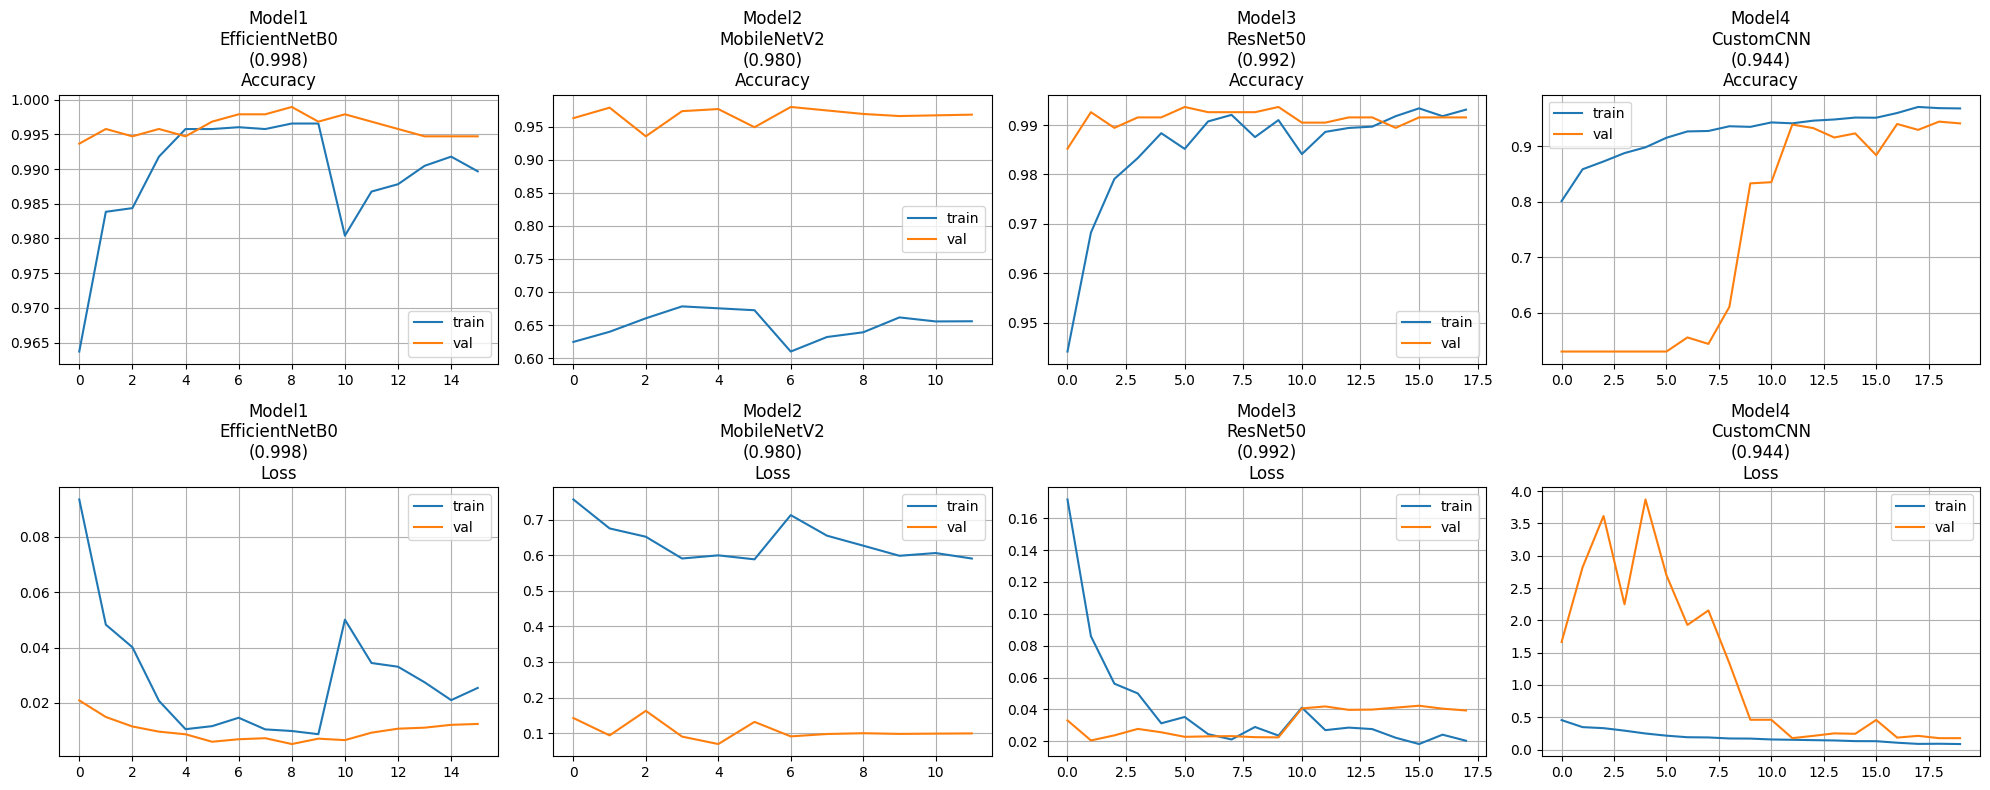

In [20]:
# Merge phase1+phase2 histories for pretrained models
def merge_histories(h1, h2):
    merged = {}
    for k in h1.history:
        merged[k] = h1.history[k] + h2.history[k]
    class FakeHistory:
        def __init__(self, d): self.history = d
    return FakeHistory(merged)

all_histories = [
    merge_histories(history1_p1, history1_p2),
    merge_histories(history2_p1, history2_p2),
    merge_histories(history3_p1, history3_p2),
    history4,
]
all_names = [
    f'Model1\nEfficientNetB0\n({val_acc1:.3f})',
    f'Model2\nMobileNetV2\n({val_acc2:.3f})',
    f'Model3\nResNet50\n({val_acc3:.3f})',
    f'Model4\nCustomCNN\n({val_acc4:.3f})',
]
plot_history(all_histories, all_names)

## 17. Summary

In [21]:
print('='*60)
print('FINAL SUMMARY')
print('='*60)
for rank, m in enumerate(model_registry, 1):
    tag = '🥇 BEST ' if rank==1 else '🥈 2nd  ' if rank==2 else '       '
    print(f'{tag} {m["name"]:35s}  val_acc={m["val_acc"]:.4f}')
print()
print('Submission CSVs:')
for path in output_paths:
    print(f'  → {path}')
print()
print('Submission column format:')
print(f'  ID col    : {SCHEMA["id_col"]}')
print(f'  Label col : {SCHEMA["label_col"]}')
print(f'  Label type: {SCHEMA["label_type"]}')
print(f'  ID has ext: {SCHEMA["id_has_ext"]}')
print()
print('Class mapping (sigmoid output):')
print(f'  p >= 0.5  →  "{CLASS_NAMES[1]}"')
print(f'  p <  0.5  →  "{CLASS_NAMES[0]}"')

FINAL SUMMARY
🥇 BEST  Model1_EfficientNetB0                val_acc=0.9979
🥈 2nd   Model3_ResNet50                      val_acc=0.9915
        Model2_MobileNetV2                   val_acc=0.9799
        Model4_CustomCNN                     val_acc=0.9440

Submission CSVs:
  → /kaggle/working/submission_rank1_Model1_EfficientNetB0.csv
  → /kaggle/working/submission_rank2_Model3_ResNet50.csv

Submission column format:
  ID col    : ID
  Label col : Label
  Label type: string
  ID has ext: True

Class mapping (sigmoid output):
  p >= 0.5  →  "muffin"
  p <  0.5  →  "chihuahua"
